## Import Libs

In [1]:
import numpy as np
from tqdm import tqdm
from Utils.utils import *
import matplotlib.pyplot as plt
%matplotlib inline

##  The loss function

In [2]:
import torch
class LogCoshLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_prime_t, y_t):
        ey_t = y_prime_t - y_t
        return torch.mean(ey_t + F.softplus(-2.0 * ey_t) - torch.tensor(math.log(2.0)).to(ey_t.device))
    
log_cosh_error = LogCoshLoss()


## Beta schedule of the Diffusion model

In [3]:

def linear_beta_schedule(timesteps):
    scale = 1000 / timesteps
    beta_start = scale * 0.0001
    beta_end = scale * 0.02
    return torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float64)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule
    as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

## Diffusion Class

In [4]:
class GaussianDiffusion:
    def __init__(
        self,
        timesteps=1000,
        beta_schedule='linear'
    ):
        self.timesteps = timesteps
        
        if beta_schedule == 'linear':
            betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f'unknown beta schedule {beta_schedule}')
        self.betas = betas
            
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.)
        
        # calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.log_one_minus_alphas_cumprod = torch.log(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / self.alphas_cumprod - 1)
        
        # calculations for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        # below: log calculation clipped because the posterior variance is 0 at the beginning
        # of the diffusion chain
        self.posterior_log_variance_clipped = torch.log(self.posterior_variance.clamp(min =1e-20))
        
        self.posterior_mean_coef1 = (
            self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
            (1.0 - self.alphas_cumprod_prev)
            * torch.sqrt(self.alphas)
            / (1.0 - self.alphas_cumprod)
        )
    
    # get the param of given timestep t
    def _extract(self, a, t, x_shape):
        batch_size = t.shape[0]
        out = a.to(t.device).gather(0, t).float()
        out = out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))
        return out
    
    # forward diffusion (using the nice property): q(x_t | x_0)
    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self._extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphas_cumprod_t = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise
    # compute train losses
    def train_losses(self, model, x_start, CWT, t):
        # generate random noise
        noise = torch.randn_like(x_start)
        # get x_t
        x_noisy = self.q_sample(x_start, t, noise=noise)
        pred_x0 = model(x_noisy,CWT, t)
        #predicted_noise = model(x_noisy,seismic_data, t)
        loss = log_cosh_error(pred_x0, x_start)
        #loss = F.mse_loss(pred_x0, x_start)
        return loss
    
    # compute train losses
    def predict_losses(self, model, x_start, CWT, t):
        # generate random noise
        noise = torch.randn_like(x_start)
        # get x_t
        x_noisy = self.q_sample(x_start, t, noise=noise)
        pred_x0 = model(x_noisy,CWT, t)
        #predicted_noise = model(x_noisy,seismic_data, t)
        loss = log_cosh_error(pred_x0, x_start)
        #loss = F.mse_loss(pred_x0, x_start)
        
        return loss, pred_x0

## Reading BP and CWT SCale of the DAS data (FORGE Example)

In [5]:
# Preprocessing the DAS data (band-pass filter, CWT).
from Utils.bp import bandpass
import py_cwt2d
import h5py
from matplotlib import pylab as plt
from Utils.cmap import cmaps
from matplotlib.colors import SymLogNorm

# Selecting the DAS data (1, or 44, or 74)
eq = 44
f = h5py.File(r'data/out_Diff_' +str(eq) + '_pre.mat')
dn = np.array(np.transpose(f.get('dn')))

# Band-pass filter if needed..
dt = 0.0005 # sampling 
BP = bandpass(dn,dt,1e-3,250,6,6,0,0)
#CWT
ss = np.arange(1,10.5,0.5) #scale
# calculate the CWT Scale.
coeffs_nsq, wav_norm_nsq = py_cwt2d.cwt_2d(BP, ss, 'mexh')
# Choose the Finest One (Last Scale).
CWTSCALE = np.abs(coeffs_nsq[:,:,-1])

## Plotting BP and CWT DAS Data.


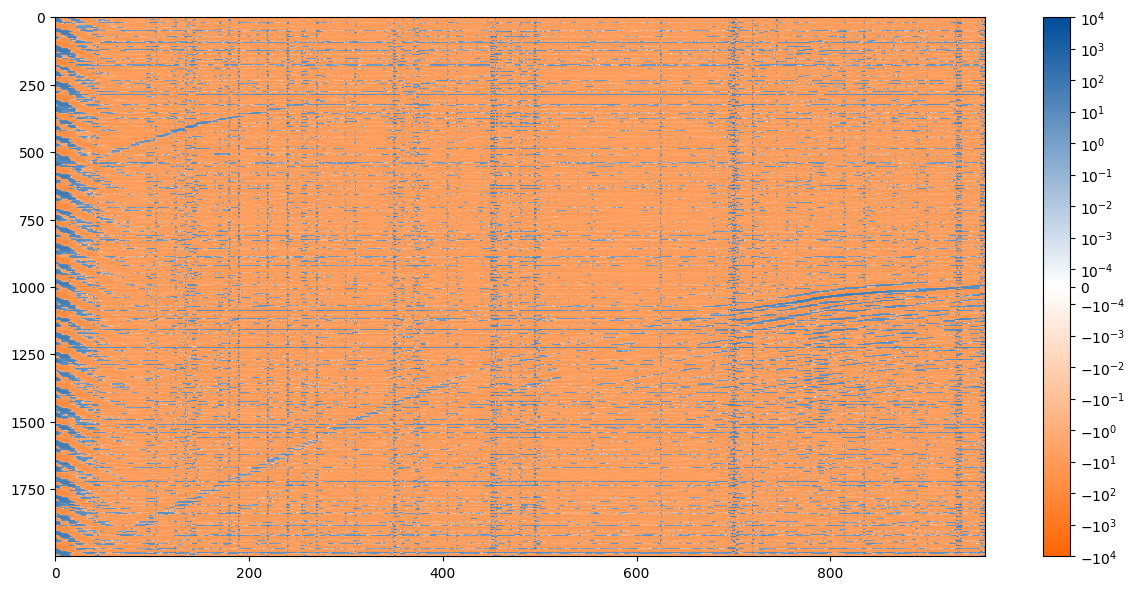

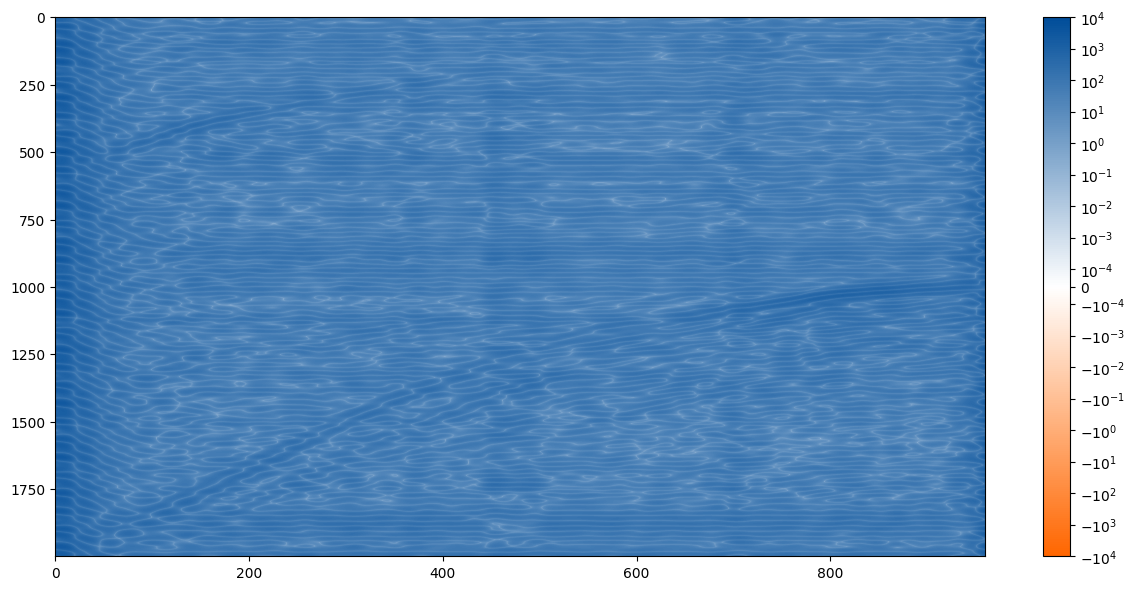

In [6]:
plt.figure(figsize=(15,7))
plt.imshow(BP, cmap=cmaps['bluorange'], 
           norm=SymLogNorm(linthresh=1e-4, linscale=0.5, vmin=-1e4, vmax=1e4, base=10))
plt.axis('tight')
plt.colorbar();


#Plotting CWT DAS Data.
plt.figure(figsize=(15,7))
plt.imshow(CWTSCALE, cmap=cmaps['bluorange'], 
           norm=SymLogNorm(linthresh=1e-4, linscale=0.5, vmin=-1e4, vmax=1e4, base=10))
plt.axis('tight')
plt.colorbar();


## Patching 

In [7]:
def patchify(inp, kernel_size, stride, inv=False, orig_size=None):
    if not inv:
        out = inp.unfold(0, kernel_size[0], stride[0]).unfold(1, kernel_size[1], stride[1])
        out = out.reshape(-1, kernel_size[0], kernel_size[1])
        input_ones = torch.ones_like(inp).unfold(0, kernel_size[0], stride[0]).unfold(1, kernel_size[1], stride[1])
        divisor = input_ones.reshape(-1, kernel_size[0], kernel_size[1])

        return out

    elif inv and orig_size is not None:
        out = inp.reshape(-1, kernel_size[0]*kernel_size[1])
        out = F.fold(out.transpose(0, 1), output_size=orig_size, kernel_size=kernel_size, stride=stride)[0]
        divisor = torch.ones_like(inp)
        divisor = divisor.reshape(-1, kernel_size[0]*kernel_size[1])
        divisor = F.fold(divisor.transpose(0, 1), output_size=orig_size, kernel_size=kernel_size, stride=stride)[0]

        return out / divisor
  

## Patch size and strides.

w1 = 48
w2 = 48
s1z = 8
s2z = 8

CWT = CWTSCALE.copy()

# Normalize the CWT Scale (if needed)
#ma = np.max(np.abs(CWT))
#dataInput = CWT/ma
#dataInput =CWT
val = np.max(np.abs(BP))/np.max(np.abs(CWT))
dataInput =CWT*val


# Patching the CWT SCALE.
dataInputP = patch(dataInput,w1,w2,s1z,s2z)
dataInput2 = np.reshape(dataInputP,(dataInputP.shape[0],1,w1,w2))

# Patching the Band-pass Filtered Data.
dataInputF = patchify(torch.tensor(BP),(w1,w2),(s1z,s2z)).reshape(-1, w1*w2).numpy()   
dataInputF = patch(BP,w1,w2,s1z,s2z)

dataInputF2 = np.reshape(dataInputF,(dataInputF.shape[0],1,w1,w2))

dataInputF2 = torch.tensor(dataInputF2).float()
dataInput2 = torch.tensor(dataInput2).float()
dataInputF = torch.tensor(dataInputF).float()

# Print the patches size
dataInput2.shape, dataInputF2.shape

(torch.Size([28175, 1, 48, 48]), torch.Size([28175, 1, 48, 48]))

## Plotting Example for forward diffusion process

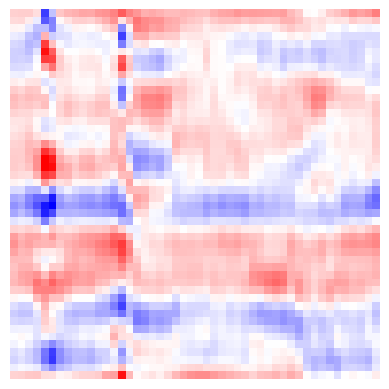

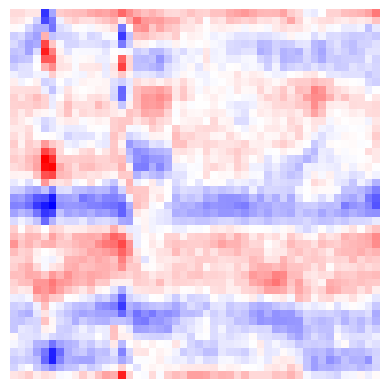

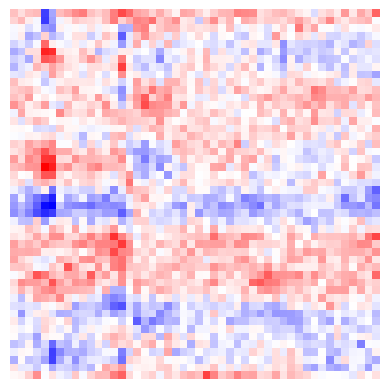

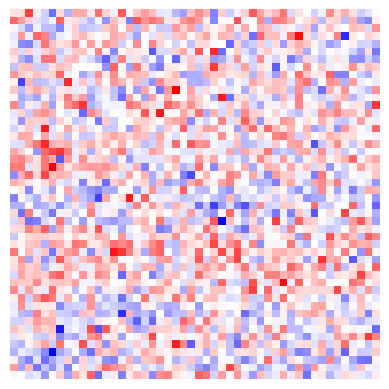

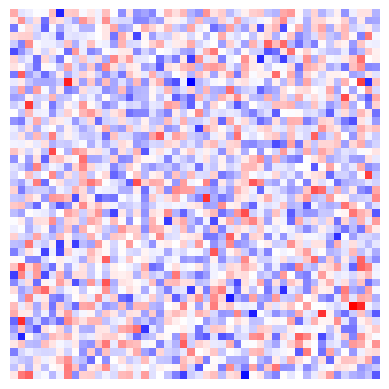

In [8]:
import scipy.io as sio
import torch.nn.functional as F

BT = 128
timesteps = 2000

gaussian_diffusion = GaussianDiffusion(timesteps=timesteps)
x_noisyall = []
for idx, t in enumerate([0, 500, 1000, 1500, 1999]):
    x_noisy = gaussian_diffusion.q_sample(dataInputF2[15000,0,:,:], t=torch.tensor([t]))
    plt.figure()
    plt.imshow(x_noisy,cmap="bwr")
    plt.axis("off")
    x_noisyall.append(x_noisy.cpu().numpy())
x_noisyall = np.array(x_noisyall)
#sio.savemat('Diffused_' + str(timesteps) + '_' + str(eq) + '.mat', {'x_noisyall':x_noisyall})

## Training Process

In [9]:
from torchsummary import summary
from Utils.CompactDiff_5 import *
from tqdm import tqdm
import os


train_dataset = torch.utils.data.TensorDataset(dataInput2, dataInputF2)
train_dataloader1 = torch.utils.data.DataLoader(train_dataset, batch_size=BT,shuffle= True)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BT)

# define model and diffusion
device = "cuda" if torch.cuda.is_available() else "cpu"
timesteps1 = torch.tensor([0])  # Example timestep tensor for the batch



D1 = 1024  # Example
DN = 1
model = DLModel(w1*w2, D1)  # Assume you defined input_dim
model = model.to(device)  # Move model to GPU if necessary

gaussian_diffusion = GaussianDiffusion(timesteps=timesteps)

# Learning Rate Schedule
A = 50
def lr_schedule(epoch):
    initial_lr = 1e-4

    if epoch <= A:
        lr = initial_lr
    elif epoch <= A + 10:
        lr = initial_lr / 2
    elif epoch <= A + 30:
        lr = initial_lr / 10
    else:
        lr = initial_lr / 20
        
    return lr

# optimzer
optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule(0))

# Folder for saving the pre-trained model
folder_name = "checkpoints"

# Check if the folder exists
if not os.path.exists(folder_name):
    # Create the folder
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

# Number of epchos
epochs = 100

for epoch in tqdm(range(epochs)):
    lossall = []
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr_schedule(epoch)
        
    for step, (CWTI,BPF) in enumerate(train_dataloader1):
        optimizer.zero_grad()
        
        batch_size = BPF.shape[0]
        BPF = BPF.to(device)
        CWTI = CWTI.to(device)
        
        # sample t uniformally for every example in the batch
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()
        
        loss = gaussian_diffusion.train_losses(model, BPF, CWTI, t)
        loss.backward()
        optimizer.step()
        lossall.append(loss.item())
        
    lossall = torch.tensor(lossall)
    print(lossall.mean().item(),'lr:', param_group['lr'] )
    
torch.save(model.state_dict(),'checkpoints/DAS_Diff_Mexh_Python' + str(eq) + '.pt')

Folder 'checkpoints' already exists.


  1%|▍                                          | 1/100 [00:06<11:18,  6.85s/it]

5.848280906677246 lr: 0.0001


  2%|▊                                          | 2/100 [00:12<09:38,  5.91s/it]

5.601475238800049 lr: 0.0001


...

3.2225866317749023 lr: 5e-06


 99%|█████████████████████████████████████████▌| 99/100 [12:34<00:08,  8.45s/it]

3.2166218757629395 lr: 5e-06


100%|█████████████████████████████████████████| 100/100 [12:43<00:00,  7.63s/it]

3.222675085067749 lr: 5e-06


## Load the pre-trained model

In [10]:
device = torch.device('cuda')
model_test = DLModel(w1*w2, D1) 
model_test.to(device)
model_test.load_state_dict(torch.load('./checkpoints/DAS_Diff_Mexh_Python' + str(eq) + '.pt'))
gaussian_diffusion = GaussianDiffusion(timesteps=timesteps)

## Inference stage

In [11]:
preall = []

for epoch in tqdm(range(1)):
    lossall = []
    for step, (CWTI,BPF) in enumerate(train_dataloader):
        optimizer.zero_grad()
        
        batch_size = BPF.shape[0]
        BPF = BPF.to(device)
        CWTI = CWTI.to(device)
        
        # sample t uniformally for every example in the batch
        #t = torch.tensor(timesteps-1).repeat(batch_size).to(device)
        # It also could be 1999
        t = torch.tensor(1999).repeat(batch_size).to(device)
        loss,pred_x0 = gaussian_diffusion.predict_losses(model_test, BPF, CWTI, t)
        
        
        # Convert pred_x0 to numpy and append to preall
        preall.append(pred_x0.detach().cpu().numpy())
        

# After the loop, concatenate all the predictions along axis 0
preall = np.concatenate(preall, axis=0)
print(preall.shape)


100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.64s/it]

(28175, 1, 48, 48)


## Unpatching

In [12]:
''' 
n1,n2 = np.shape(BP)
outB = patchify(torch.tensor(preall), (w1,w2), (s1z,s2z), inv=True, orig_size=(n1,n2))
outB = np.array(outB)
d2 = outB

# After DL Denoising, Applying the dip filter in fk.
d2 = outB - fkdip(outB,0.02)


outB.shape, n1,n2, preall.shape
'''

' \nn1,n2 = np.shape(BP)\noutB = patchify(torch.tensor(preall), (w1,w2), (s1z,s2z), inv=True, orig_size=(n1,n2))\noutB = np.array(outB)\nd2 = outB\n\n# After DL Denoising, Applying the dip filter in fk.\nd2 = outB - fkdip(outB,0.02)\n\n\noutB.shape, n1,n2, preall.shape\n'

In [13]:
from Utils.fk import *
out = np.reshape(preall,(preall.shape[0],w1*w2))     
outA = np.transpose(out)
n1,n2=np.shape(BP)
outB = patch_inv(outA,n1,n2,w1,w2,s1z,s2z)
outB = np.array(outB)
d2 = outB
# After DL Denoising, Applying the dip filter in fk.
d2 = outB - fkdip(outB,0.02)



## Plotting the denoised DAS data

Text(0.5, 1.0, 'Remove Noise Section')

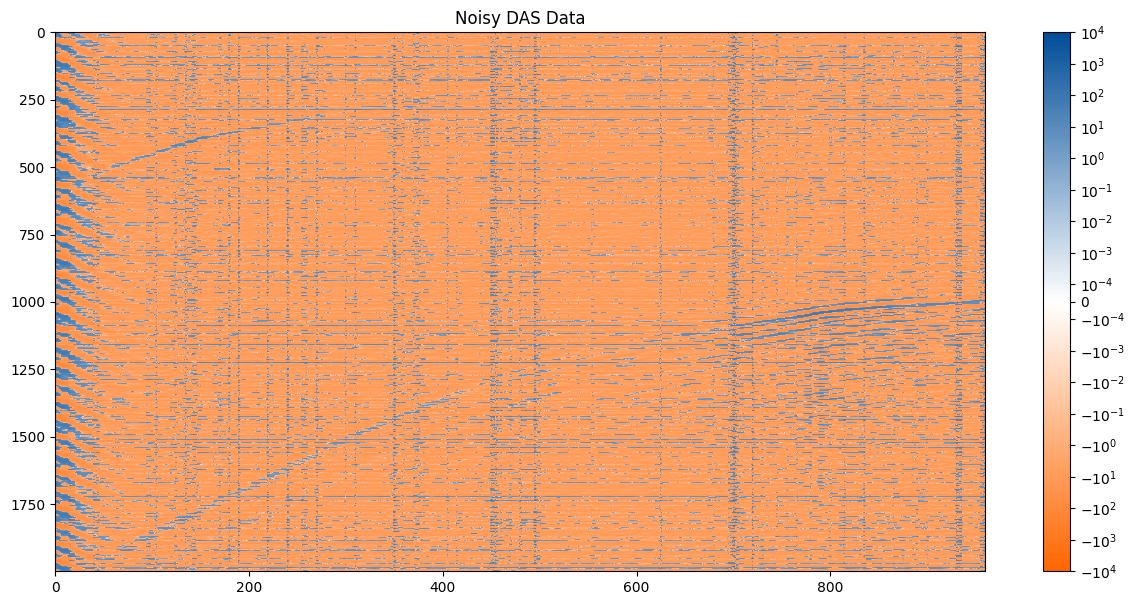

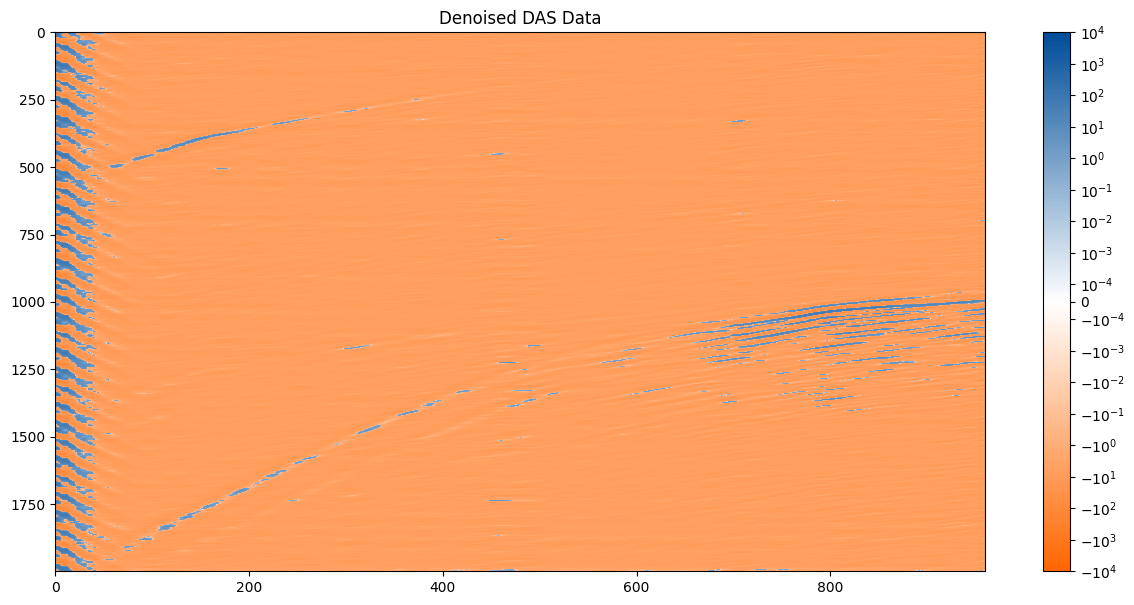

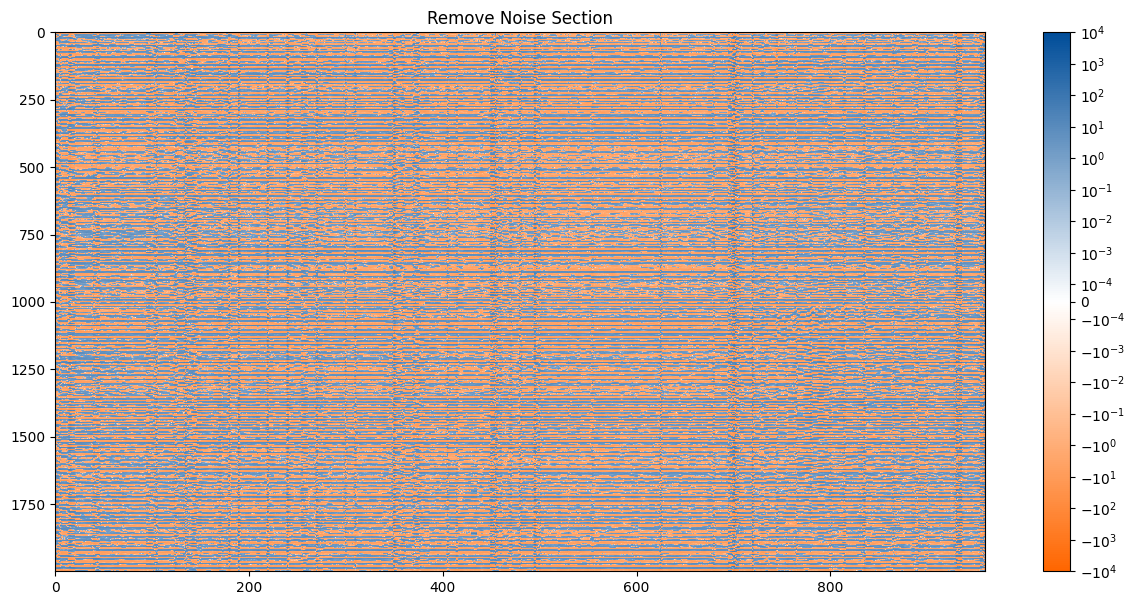

In [14]:
# Noisy DAS Data.
plt.figure(figsize=(15,7))
plt.imshow(BP, cmap=cmaps['bluorange'], 
           norm=SymLogNorm(linthresh=1e-4, linscale=0.5, vmin=-1e4, vmax=1e4, base=10))
plt.axis('tight')
plt.colorbar();
plt.title('Noisy DAS Data')


# Denoised DAS Data.
plt.figure(figsize=(15,7))
plt.imshow(d2, cmap=cmaps['bluorange'], 
           norm=SymLogNorm(linthresh=1e-4, linscale=0.5, vmin=-1e4, vmax=1e4, base=10))
plt.axis('tight')
plt.colorbar();
plt.title('Denoised DAS Data')


# Remove Noise Section.
plt.figure(figsize=(15,7))
plt.imshow(BP-d2, cmap=cmaps['bluorange'], 
           norm=SymLogNorm(linthresh=1e-4, linscale=0.5, vmin=-1e4, vmax=1e4, base=10))
plt.axis('tight')
plt.colorbar();
plt.title('Remove Noise Section')

## Save in ".mat" format in case you want to plot on Matlab.

In [15]:
import scipy.io as sio
sio.savemat('Diff_out_t_C_Python' + str(timesteps) + '_' + str(eq) + '.mat', {'d2':d2})